# Trader Performance vs Market Sentiment
 **Objective**

Analyze how market sentiment (Fear vs Greed) affects trader behavior and performance.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data (replace with your file names if different)
sentiment = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

# Preview data
print("Sentiment Data:")
display(sentiment.head())

print("\nTrades Data:")
display(trades.head())


Sentiment Data:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Trades Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [24]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nSentiment Info:")
print(sentiment.info())

print("\nTrades Info:")
print(trades.info())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Sentiment Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Trades Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  ob

In [25]:
# Convert date columns

# Sentiment dataset
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Trades dataset
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date

# Check missing values
print("Missing values in Sentiment:\n", sentiment.isnull().sum())
print("\nMissing values in Trades:\n", trades.isnull().sum())

# Remove duplicates
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

Missing values in Sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64


In [26]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print("Merged Data:")
display(merged.head())

Merged Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [27]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'timestamp', 'value', 'classification']


## Analysis: Market Sentiment vs Trader Behavior

In [28]:
# Daily PnL per account
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

# Win/Loss column
merged['win'] = merged['Closed PnL'] > 0

# Win rate per account
win_rate = merged.groupby('Account')['win'].mean().reset_index()

# Number of trades per day
trades_per_day = merged.groupby('date').size()

# Average trade size (use Size USD for better meaning)
avg_trade_size = merged.groupby('Account')['Size USD'].mean()

# Long/Short count
long_short = merged.groupby('Side').size()



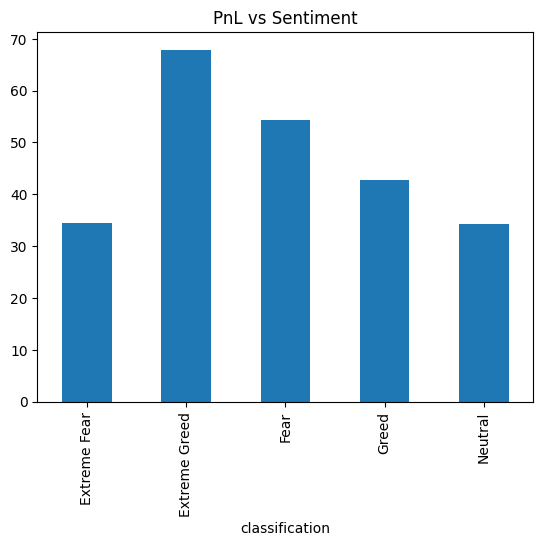

In [29]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()

pnl_by_sentiment.plot(kind='bar', title='PnL vs Sentiment')
plt.show()

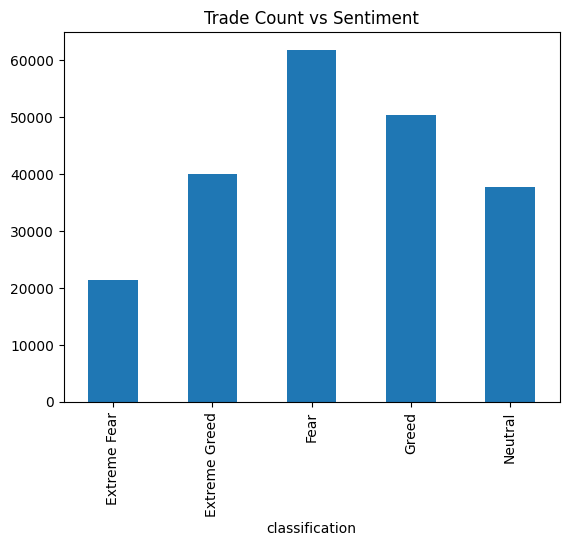

In [30]:
trades_sentiment = merged.groupby('classification').size()

trades_sentiment.plot(kind='bar', title='Trade Count vs Sentiment')
plt.show()

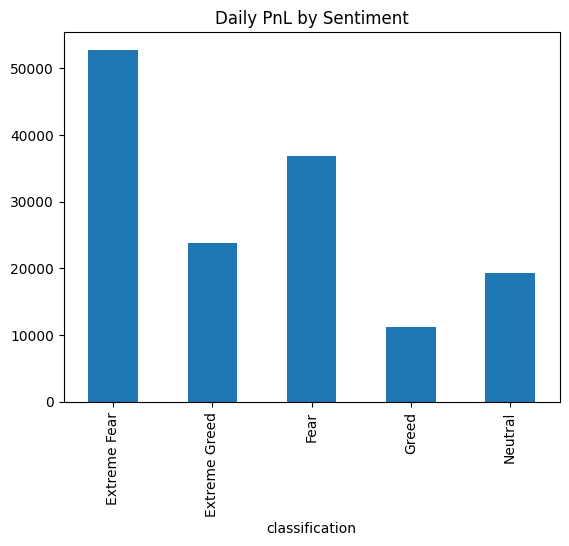

In [31]:
# Daily PnL consistency by sentiment
daily_pnl_sentiment = merged.groupby(['date', 'classification'])['Closed PnL'].sum().reset_index()

daily_pnl_sentiment.groupby('classification')['Closed PnL'].mean().plot(kind='bar', title='Daily PnL by Sentiment')
plt.show()

## Trader Segmentation Analysis

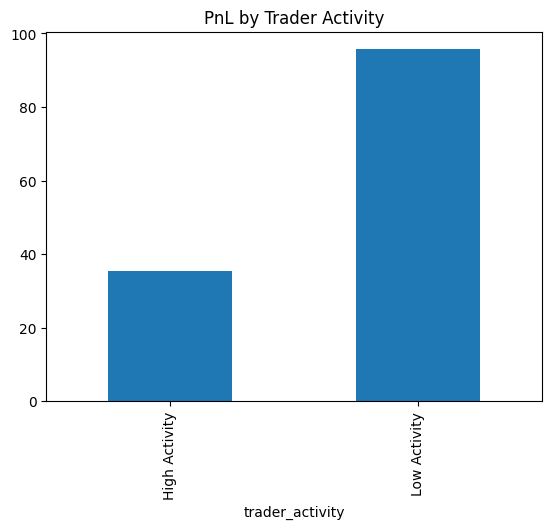

In [32]:
trade_counts = merged.groupby('Account').size()

merged['trader_activity'] = merged['Account'].map(
    lambda x: 'High Activity' if trade_counts[x] > trade_counts.mean() else 'Low Activity'
)

merged.groupby('trader_activity')['Closed PnL'].mean().plot(kind='bar', title='PnL by Trader Activity')
plt.show()

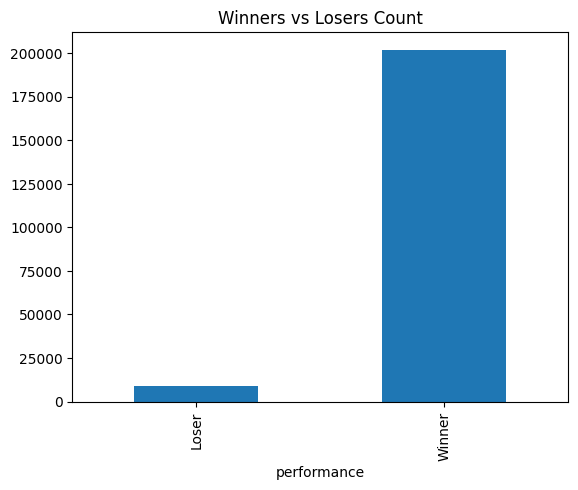

In [33]:
total_pnl = merged.groupby('Account')['Closed PnL'].sum()

merged['performance'] = merged['Account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

merged.groupby('performance').size().plot(kind='bar', title='Winners vs Losers Count')
plt.show()



## Key Insights:

1. Traders generate higher profits during Extreme Greed periods, indicating favorable market conditions.

2. Trading activity is highest during Fear periods, suggesting panic-driven or reactive trading behavior.

3. Increased trading activity during Fear does not lead to higher profitability, indicating inefficient decision-making.

4. Emotional bias during Fear periods negatively impacts trader performance, leading to high activity but lower returns.

## Strategy Recommendations

1. During Fear periods, traders should reduce overtrading and focus only on high-confidence trades to minimize losses caused by volatility.

2. During Greed periods, traders can adopt trend-following strategies with controlled risk exposure to maximize profitability.

## Conclusion

Market sentiment plays a significant role in shaping trader behavior and performance.
While Greed-driven markets offer higher profitability, Fear-driven markets lead to excessive trading with lower returns.
This highlights the importance of disciplined and sentiment-aware trading strategies.